First 5 Records:
   age  sex     bmi  children  smoker  region      charges  insuranceclaim
0   19    0  27.900         0       1       3  16884.92400               1
1   18    1  33.770         1       0       2   1725.55230               1
2   28    1  33.000         3       0       2   4449.46200               0
3   33    1  22.705         0       0       1  21984.47061               0
4   32    1  28.880         0       0       1   3866.85520               1

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64


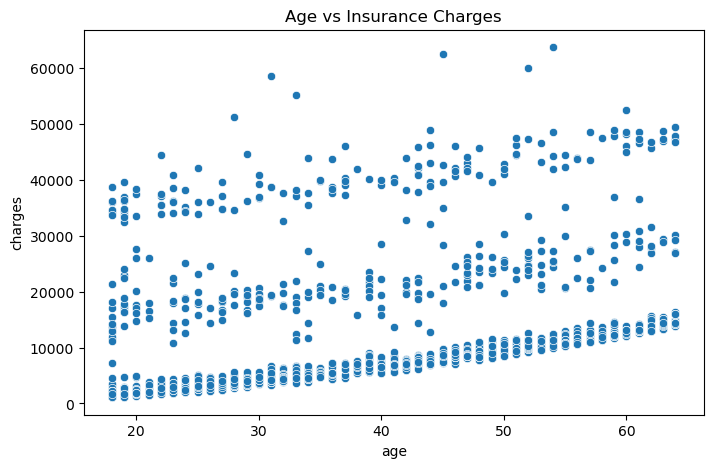

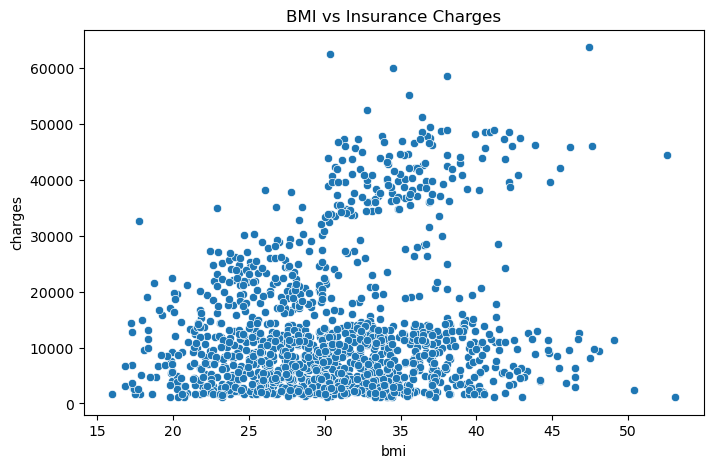

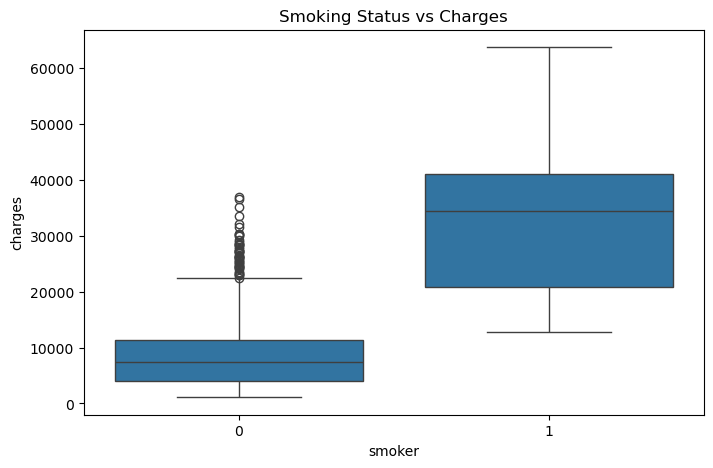


Model Evaluation
MAE : 4202.073483424077
RMSE: 5811.659212863656


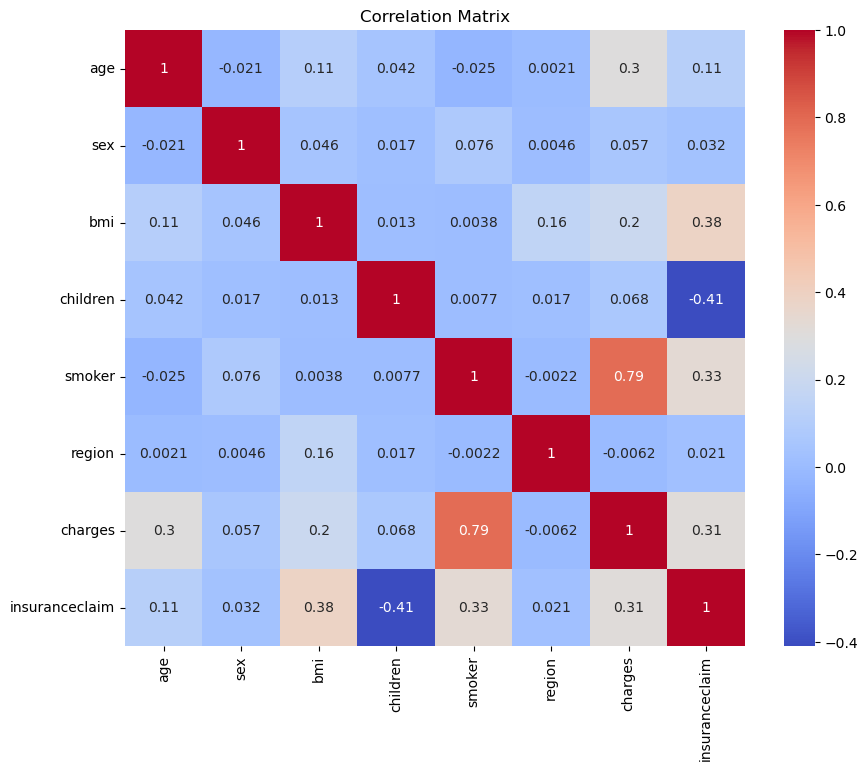


Conclusion:
- Age and smoking status strongly affect insurance charges.
- Smokers generally pay much higher charges.
- Linear Regression predicts charges with reasonable accuracy.


In [1]:

# INSURANCE CLAIM AMOUNT PREDICTION
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. Load Dataset
df = pd.read_csv(r"G:\insurance2.csv")

# Display first few rows
print("First 5 Records:")
print(df.head())

# 3. Basic Data Exploration
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# 4. Data Visualization

# Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

# BMI vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

# Smoking Status vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking Status vs Charges")
plt.show()

# 5. Convert Categorical Variables to Numeric
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

# 6. Feature Selection
X = df.drop('charges', axis=1)
y = df['charges']

# 7. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 8. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 9. Make Predictions
y_pred = model.predict(X_test)

# 10. Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation")
print("MAE :", mae)
print("RMSE:", rmse)

# 11. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 12. Conclusion
print("\nConclusion:")
print("- Age and smoking status strongly affect insurance charges.")
print("- Smokers generally pay much higher charges.")
print("- Linear Regression predicts charges with reasonable accuracy.")